Data source : https://www.kaggle.com/c/home-credit-default-risk/data

But notebook : Feature Engineering / Reduction

- utiliser les donnes agrégées précédemment
- réduire le dataframe (optimisation de futurs temps de calcul / temps de modélisation) tout en ayant le moins de données manquantes dans les features restantes
   - verification des types et choix de types plus avantageux en poids si possible
   - entrainement sur différents modèles et extraction des features notables via SHAPE ou autre (knn most important features)
   - éviter de "créer" des informations ex-nihilo avec de l'inputing : favoriser la sélection / suppression en préservant au mieux l'intégrité des données

# Imports

## libraries

In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import os

import numpy as np
import pandas as pd
import inspect

import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# import utils from parent directory
import sys
from pathlib import Path
parent_dir = str(Path().resolve().parents[1])
sys.path.insert(0, parent_dir)

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

In [18]:
import gc
import time
from contextlib import contextmanager
import re

In [19]:
# https://numpy.org/doc/stable/release/2.0.0-notes.html#representation-of-numpy-scalars-changed
np.set_printoptions(legacy='1.21')

In [20]:
import mlflow
import mlflow.lightgbm
import mlflow.xgboost
from mlflow import MlflowClient
from mlflow.models.signature import infer_signature
from pprint import pprint

In [21]:
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn import model_selection

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score,fbeta_score, make_scorer

from sklearn.ensemble import RandomForestClassifier

In [22]:
import xgboost as xgb
import shap

## data

In [12]:
csv_path_output = '../data/output/'
file_name = 'df_cleaned.csv'

df = pd.read_csv(f'{csv_path_output + file_name}', encoding='ISO-8859-1')
df.drop(df.filter(regex="Unname"),axis=1, inplace=True)

In [13]:
df.shape

(74878, 38)

In [14]:
df.head()

,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_EMPLOYED,INSTAL_DPD_MEAN,CODE_GENDER,PAYMENT_RATE,DAYS_EMPLOYED_PERC,DAYS_BIRTH,PREV_CNT_PAYMENT_MEAN,AMT_GOODS_PRICE,...,INSTAL_PAYMENT_PERC_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,PREV_APP_CREDIT_PERC_MIN,INSTAL_AMT_PAYMENT_MIN,BURO_CREDIT_ACTIVE_Closed_MEAN,DAYS_REGISTRATION,APPROVED_AMT_ANNUITY_MAX,INSTAL_AMT_PAYMENT_MEAN,ACTIVE_DAYS_CREDIT_ENDDATE_MEAN,TARGET
0,0.262949,0.139376,-637.0,0.000000,0,0.060749,0.067329,-9461,24.000,351000.0,...,1.000000,-315.42105,1.000000,9251.775,0.750000,-3648.0,9251.775,11559.247,780.00,1.0
1,0.715042,0.176653,-2717.0,3.527027,1,0.072732,0.202173,-13439,17.000,67500.0,...,0.837838,-1297.58100,0.909881,3.960,0.428571,-311.0,14480.460,8391.646,381.75,0.0
2,0.706428,0.556727,-7804.0,0.000000,1,0.050000,0.440456,-17718,18.000,157500.0,...,1.000000,-142.42857,0.863260,6765.975,0.000000,-8751.0,6765.975,6765.975,940.00,0.0
3,0.457143,0.358951,-4306.0,0.000000,1,0.065367,0.386327,-11146,21.000,450000.0,...,1.000000,-1105.87500,0.906651,23531.176,0.333333,-114.0,42778.844,119294.590,899.00,0.0
4,0.651406,0.461482,-3494.0,0.000000,1,0.049220,0.180718,-19334,8.625,225000.0,...,1.000000,-730.66670,0.949873,9035.685,0.666667,-2419.0,9035.685,11820.645,1409.00,0.0


# Explo

## Valeurs manquantes

In [ ]:
# https://medium.com/@kavyasree42/how-to-handle-missing-data-in-python-simple-to-advanced-techniques-machine-learning-brain-ffae3c1a694f

In [23]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))
    
# Function to calculate missing values by column
def missing_values_table(df):
    # Taux de valeurs manquantes :
    print("Taux de valeurs manquantes dans le df avant imputation :" , round(df.isna().mean().mean(),4))
    # Total missing values
    mis_val = df.isnull().sum()
    
    # Percentage of missing values
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    
    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    
    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    
    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    
    # Print some summary information
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
           "There are " + str(mis_val_table_ren_columns.shape[0]) +
           " columns that have missing values.")
    
    # Return the dataframe with missing information
    return mis_val_table_ren_columns

In [24]:
#  Statistiques sur les valeurs manquantes :
missing_values = missing_values_table(df)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Séparation du jeu de données en jeu de  training/validation et jeu de test
train_df = df[df['TARGET'].notnull()] # partie du jeu de données qui contient une target
test_df = df[df['TARGET'].isnull()] # partie du jeu de données qui n'a pas de target
print(train_df.shape, test_df.shape)
train_df["TARGET"].value_counts()/train_df.shape[0]

# Taux de valeurs manquantes :
print("Taux de valeurs manquantes dans jeu de train avant imputation :" , round(train_df.isna().mean().mean(),4))
print("Taux de valeurs manquantes dans jeu de test avant imputation :" , round(test_df.isna().mean().mean(),4))

Taux de valeurs manquantes dans le df avant imputation : 0.0
Your selected dataframe has 38 columns.
There are 0 columns that have missing values.
(74878, 38) (0, 38)
Taux de valeurs manquantes dans jeu de train avant imputation : 0.0
Taux de valeurs manquantes dans jeu de test avant imputation : nan


# Typage

In [25]:
df.head()

,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_EMPLOYED,INSTAL_DPD_MEAN,CODE_GENDER,PAYMENT_RATE,DAYS_EMPLOYED_PERC,DAYS_BIRTH,PREV_CNT_PAYMENT_MEAN,AMT_GOODS_PRICE,...,INSTAL_PAYMENT_PERC_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,PREV_APP_CREDIT_PERC_MIN,INSTAL_AMT_PAYMENT_MIN,BURO_CREDIT_ACTIVE_Closed_MEAN,DAYS_REGISTRATION,APPROVED_AMT_ANNUITY_MAX,INSTAL_AMT_PAYMENT_MEAN,ACTIVE_DAYS_CREDIT_ENDDATE_MEAN,TARGET
0,0.262949,0.139376,-637.0,0.000000,0,0.060749,0.067329,-9461,24.000,351000.0,...,1.000000,-315.42105,1.000000,9251.775,0.750000,-3648.0,9251.775,11559.247,780.00,1.0
1,0.715042,0.176653,-2717.0,3.527027,1,0.072732,0.202173,-13439,17.000,67500.0,...,0.837838,-1297.58100,0.909881,3.960,0.428571,-311.0,14480.460,8391.646,381.75,0.0
2,0.706428,0.556727,-7804.0,0.000000,1,0.050000,0.440456,-17718,18.000,157500.0,...,1.000000,-142.42857,0.863260,6765.975,0.000000,-8751.0,6765.975,6765.975,940.00,0.0
3,0.457143,0.358951,-4306.0,0.000000,1,0.065367,0.386327,-11146,21.000,450000.0,...,1.000000,-1105.87500,0.906651,23531.176,0.333333,-114.0,42778.844,119294.590,899.00,0.0
4,0.651406,0.461482,-3494.0,0.000000,1,0.049220,0.180718,-19334,8.625,225000.0,...,1.000000,-730.66670,0.949873,9035.685,0.666667,-2419.0,9035.685,11820.645,1409.00,0.0


In [26]:
df.dtypes

EXT_SOURCE_2                           float64
EXT_SOURCE_3                           float64
DAYS_EMPLOYED                          float64
INSTAL_DPD_MEAN                        float64
CODE_GENDER                              int64
PAYMENT_RATE                           float64
DAYS_EMPLOYED_PERC                     float64
DAYS_BIRTH                               int64
PREV_CNT_PAYMENT_MEAN                  float64
AMT_GOODS_PRICE                        float64
AMT_ANNUITY                            float64
ANNUITY_INCOME_PERC                    float64
INSTAL_AMT_PAYMENT_SUM                 float64
APPROVED_AMT_DOWN_PAYMENT_MAX          float64
BURO_AMT_CREDIT_SUM_DEBT_MEAN          float64
NAME_EDUCATION_TYPE_Highereducation      int64
AMT_CREDIT                             float64
ACTIVE_DAYS_CREDIT_MAX                 float64
BURO_DAYS_CREDIT_MEAN                  float64
PREV_APP_CREDIT_PERC_MEAN              float64
INSTAL_PAYMENT_DIFF_MEAN               float64
POS_MONTHS_BA

In [27]:
# Vérification des dtypes actuels
print("Dtypes initiaux :")
print(df.dtypes.value_counts())
print("\nInfos avant conversion :")
print(df.info())
df_memory_usage_gb = df.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df_memory_usage_gb} Gb')

# Analyse de la distribution des données
df2 = df.copy()
df2 = df2.convert_dtypes()

# Vérification des dtypes après conversion
print("\nDtypes après conversion :")
print(df.dtypes.value_counts())
print("\nInfos sur le DataFrame :")
print(df.info())
df2_memory_usage_gb = df2.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df2_memory_usage_gb} Gb')
del df2
gc.collect()

Dtypes initiaux :
float64    34
int64       4
dtype: int64

Infos avant conversion :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74878 entries, 0 to 74877
Data columns (total 38 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   EXT_SOURCE_2                         74878 non-null  float64
 1   EXT_SOURCE_3                         74878 non-null  float64
 2   DAYS_EMPLOYED                        74878 non-null  float64
 3   INSTAL_DPD_MEAN                      74878 non-null  float64
 4   CODE_GENDER                          74878 non-null  int64  
 5   PAYMENT_RATE                         74878 non-null  float64
 6   DAYS_EMPLOYED_PERC                   74878 non-null  float64
 7   DAYS_BIRTH                           74878 non-null  int64  
 8   PREV_CNT_PAYMENT_MEAN                74878 non-null  float64
 9   AMT_GOODS_PRICE                      74878 non-null  float64
 10  AMT_ANNUI

1411

In [28]:
# Vérification des dtypes actuels
print("Dtypes initiaux :")
print(df.dtypes.value_counts())
print("\nInfos avant conversion :")
print(df.info())
df_memory_usage_gb = df.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df_memory_usage_gb} Gb')

# Analyse de la distribution des données
for column in df.columns:
    if df[column].dtype == 'int64':
        min_val, max_val = df[column].min(), df[column].max()
        if min_val >= np.iinfo(np.int8).min and max_val <= np.iinfo(np.int8).max:
            df[column] = df[column].astype(np.int8)
        elif min_val >= np.iinfo(np.int16).min and max_val <= np.iinfo(np.int16).max:
            df[column] = df[column].astype(np.int16)
        elif min_val >= np.iinfo(np.int32).min and max_val <= np.iinfo(np.int32).max:
            df[column] = df[column].astype(np.int32)
    elif df[column].dtype == 'float64':
        df[column] = df[column].astype(np.float32)

# Vérification des dtypes après conversion
print("\nDtypes après conversion :")
print(df.dtypes.value_counts())
print("\nInfos sur le DataFrame :")
print(df.info())
df_memory_usage_gb = df.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df_memory_usage_gb} Gb')

Dtypes initiaux :
float64    34
int64       4
dtype: int64

Infos avant conversion :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74878 entries, 0 to 74877
Data columns (total 38 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   EXT_SOURCE_2                         74878 non-null  float64
 1   EXT_SOURCE_3                         74878 non-null  float64
 2   DAYS_EMPLOYED                        74878 non-null  float64
 3   INSTAL_DPD_MEAN                      74878 non-null  float64
 4   CODE_GENDER                          74878 non-null  int64  
 5   PAYMENT_RATE                         74878 non-null  float64
 6   DAYS_EMPLOYED_PERC                   74878 non-null  float64
 7   DAYS_BIRTH                           74878 non-null  int64  
 8   PREV_CNT_PAYMENT_MEAN                74878 non-null  float64
 9   AMT_GOODS_PRICE                      74878 non-null  float64
 10  AMT_ANNUI

In [29]:
df['TARGET'].value_counts(dropna=False)

0.0    69239
1.0     5639
Name: TARGET, dtype: int64

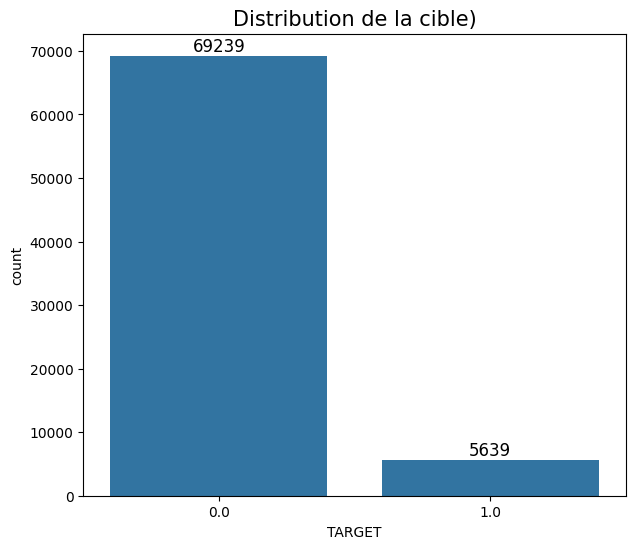

In [30]:
fig,ax=plt.subplots(figsize=(7,6))
plt.title("Distribution de la cible)", fontsize=15)
sns.countplot(x='TARGET', data=df)
for container in ax.containers:
    ax.bar_label(container,size=12,fmt='%.0f')
plt.show()

In [31]:
# Séparer les données en X_train et X_test
X_train = df[df['TARGET'].notna()]
X_test = df[df['TARGET'].isna()]

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)

Dimensions de X_train : (74878, 38)
Dimensions de X_test : (0, 38)


In [32]:
X_train['TARGET'].value_counts(dropna=False)

0.0    69239
1.0     5639
Name: TARGET, dtype: int64

In [33]:
# Compter le nombre d'éléments ayant TARGET à 1
count_target_1 = df['TARGET'].value_counts()[1]

# Sélectionner aléatoirement un nombre similaire d'éléments ayant TARGET à 0
df_target_0 = df[df['TARGET'] == 0]
df_target_0_sampled = df_target_0.sample(n=count_target_1, random_state=42)

# Sélectionner tous les éléments ayant TARGET à 1
df_target_1 = df[df['TARGET'] == 1]

# Combiner les deux ensembles pour former le nouvel ensemble X_train
X_train = pd.concat([df_target_0_sampled, df_target_1])

# Afficher les dimensions du nouvel ensemble X_train
print("Dimensions de X_train :", X_train.shape)
print("Décompte des valeurs de TARGET dans X_train :")
print(X_train['TARGET'].value_counts(dropna=False))

Dimensions de X_train : (11278, 38)
Décompte des valeurs de TARGET dans X_train :
0.0    5639
1.0    5639
Name: TARGET, dtype: int64


In [34]:
# Vérifier les valeurs manquantes dans X_train
missing_values = X_train.isna().sum()

# Afficher les valeurs manquantes par colonne
print("Valeurs manquantes dans X_train :")
print(missing_values.sum())

Valeurs manquantes dans X_train :
0


In [35]:
# Calculer le pourcentage de valeurs manquantes par colonne
missing_percentages = X_train.isna().mean() * 100

# Créer un DataFrame pour afficher les résultats
missing_table = pd.DataFrame({
    'Feature': missing_percentages.index,
    'Missing Percentage': missing_percentages.values
}).sort_values(by='Missing Percentage', ascending=False)

# Ajouter une ligne pour le total
total_missing_percentage = missing_percentages.mean()
missing_table = pd.concat([missing_table, pd.DataFrame({
    'Feature': ['Total'],
    'Missing Percentage': [total_missing_percentage]
})], ignore_index=True)

# Afficher le tableau
pd.set_option('display.max_rows', None)
print("Pourcentage de valeurs manquantes par feature :")
print(missing_table)

Pourcentage de valeurs manquantes par feature :
                                Feature  Missing Percentage
0                          EXT_SOURCE_2                 0.0
1              INSTAL_PAYMENT_PERC_MEAN                 0.0
2               POS_MONTHS_BALANCE_SIZE                 0.0
3             APPROVED_CNT_PAYMENT_MEAN                 0.0
4                       DAYS_ID_PUBLISH                 0.0
5             APPROVED_AMT_ANNUITY_MEAN                 0.0
6        ACTIVE_DAYS_CREDIT_ENDDATE_MAX                 0.0
7                  BURO_DAYS_CREDIT_MAX                 0.0
8                        TOTALAREA_MODE                 0.0
9        INSTAL_DAYS_ENTRY_PAYMENT_MEAN                 0.0
10                         EXT_SOURCE_3                 0.0
11             PREV_APP_CREDIT_PERC_MIN                 0.0
12               INSTAL_AMT_PAYMENT_MIN                 0.0
13       BURO_CREDIT_ACTIVE_Closed_MEAN                 0.0
14                    DAYS_REGISTRATION             

In [36]:
def missing_values_count(df):
    # Calculer le pourcentage de valeurs manquantes par colonne
    missing_percentages = df.isna().mean() * 100
    
    # Créer des bins pour les pourcentages de valeurs manquantes
    bins = [0, 0.01, 20, 40, 60, 100]  # 0%, 0-20%, 20-40%, 40-60%, 60-100%
    labels = ['0%', '0-20%', '20-40%', '40-60%', '60-100%']
    
    # Classer les caractéristiques dans les bins
    missing_bins = pd.cut(missing_percentages, bins=bins, labels=labels, right=False)
    
    # Compter le nombre de variables par bin
    bin_counts = missing_bins.value_counts().sort_index()
    
    # Calculer le pourcentage de variables dans chaque bin par rapport au total
    total_variables = len(missing_percentages)
    bin_percentages = (bin_counts / total_variables) * 100
    
    # Créer un DataFrame pour afficher les résultats
    bin_summary = pd.DataFrame({
        'Number of Variables': bin_counts,
        'Percentage of Total': bin_percentages
    })
    
    # Afficher le nombre de variables par bin et leur pourcentage par rapport au total
    print("Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :")
    print(bin_summary)

In [37]:
missing_values_count(df)

Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :
         Number of Variables  Percentage of Total
0%                        38                100.0
0-20%                      0                  0.0
20-40%                     0                  0.0
40-60%                     0                  0.0
60-100%                    0                  0.0


# Modélisations + feature importance

In [38]:
# Séparer les caractéristiques et la cible
X = X_train.drop(columns=['TARGET'])
y = X_train['TARGET']

# Remplacer les valeurs infinies par NaN ___ "XGBoostError : Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`"
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remplacer les NaN par la moyenne de la colonne
#X.fillna(X.mean(), inplace=True)

In [39]:
X.head()

,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_EMPLOYED,INSTAL_DPD_MEAN,CODE_GENDER,PAYMENT_RATE,DAYS_EMPLOYED_PERC,DAYS_BIRTH,PREV_CNT_PAYMENT_MEAN,AMT_GOODS_PRICE,...,TOTALAREA_MODE,INSTAL_PAYMENT_PERC_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,PREV_APP_CREDIT_PERC_MIN,INSTAL_AMT_PAYMENT_MIN,BURO_CREDIT_ACTIVE_Closed_MEAN,DAYS_REGISTRATION,APPROVED_AMT_ANNUITY_MAX,INSTAL_AMT_PAYMENT_MEAN,ACTIVE_DAYS_CREDIT_ENDDATE_MEAN
16395,0.558437,0.511892,-317.0,0.000000,1,0.029384,0.022732,-13945,6.75,733500.0,...,0.2468,1.000000,-1376.062500,0.000000,5154.975098,0.000000,-4287.0,38250.000000,7025.188965,837.000000
45128,0.684860,0.235311,-105.0,0.285714,1,0.048265,0.007076,-14838,10.80,675000.0,...,0.0641,0.952381,-963.452393,0.803714,2019.510010,0.500000,-8363.0,42035.535156,19814.937500,11265.333008
30937,0.680083,0.368969,-4274.0,0.166667,0,0.050000,0.248257,-17216,12.00,540000.0,...,0.3151,1.000000,-726.916687,1.130600,11191.905273,0.285714,-5817.0,11352.105469,11338.754883,787.200012
4564,0.724306,0.673830,-4324.0,0.316667,0,0.030415,0.191718,-22554,18.00,1354500.0,...,0.0946,0.900000,-388.116669,0.834725,85.230003,0.000000,-6777.0,24750.000000,36024.687500,154.000000
69110,0.672809,0.750375,-1001.0,0.472222,1,0.029240,0.058354,-17154,9.50,1125000.0,...,0.0787,1.072668,-1058.944458,1.000000,5202.899902,0.750000,-8877.0,30969.765625,20772.041016,1919.000000


In [40]:
y.head()

16395    0.0
45128    0.0
30937    0.0
4564     0.0
69110    0.0
Name: TARGET, dtype: float32

In [41]:
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## XGBoost

### Model

In [42]:
# Convertir les données en DMatrix pour XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Définir les paramètres du modèle XGBoost
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

# Entraîner le modèle XGBoost
xgb_model = xgb.train(params, dtrain, num_boost_round=100)

In [43]:
# Prédire les probabilités pour la classe positive
y_pred_proba = xgb_model.predict(dtest)

# Calculer l'AUC-ROC
auc_roc = roc_auc_score(y_test, y_pred_proba)
auc_roc

0.7482456915722271

### Feature Importance (SHAPE)

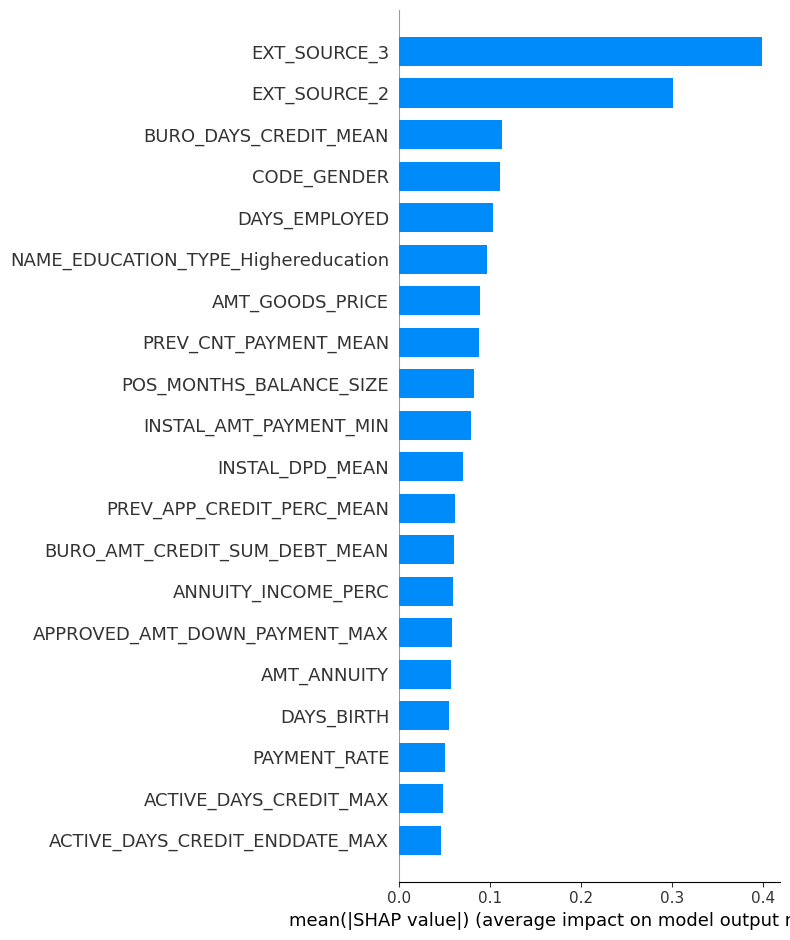

In [44]:
# Calculer les valeurs SHAP
model1_explainer = shap.TreeExplainer(xgb_model)
model1_shap_values = model1_explainer.shap_values(X_test)

# Visualiser les valeurs SHAP
shap.summary_plot(model1_shap_values, X_test, plot_type='bar')

## LightGBM

### Model

In [45]:
# Convertir les données en Dataset pour LightGBM
dtrain = lgb.Dataset(X_train, label=y_train)

# Définir les paramètres du modèle LightGBM
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

# Entraîner le modèle LightGBM
LGBM_model = lgb.train(params, dtrain, num_boost_round=100)

[LightGBM] [Info] Number of positive: 3972, number of negative: 3922
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000807 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8597
[LightGBM] [Info] Number of data points in the train set: 7894, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503167 -> initscore=0.012668
[LightGBM] [Info] Start training from score 0.012668
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [46]:
# Prédire les probabilités pour la classe positive
y_pred_proba = LGBM_model.predict(X_test)

# Calculer l'AUC-ROC
auc_roc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC-ROC: {auc_roc}")

AUC-ROC: 0.7471213969203829


### Feature Importance (SHAP)

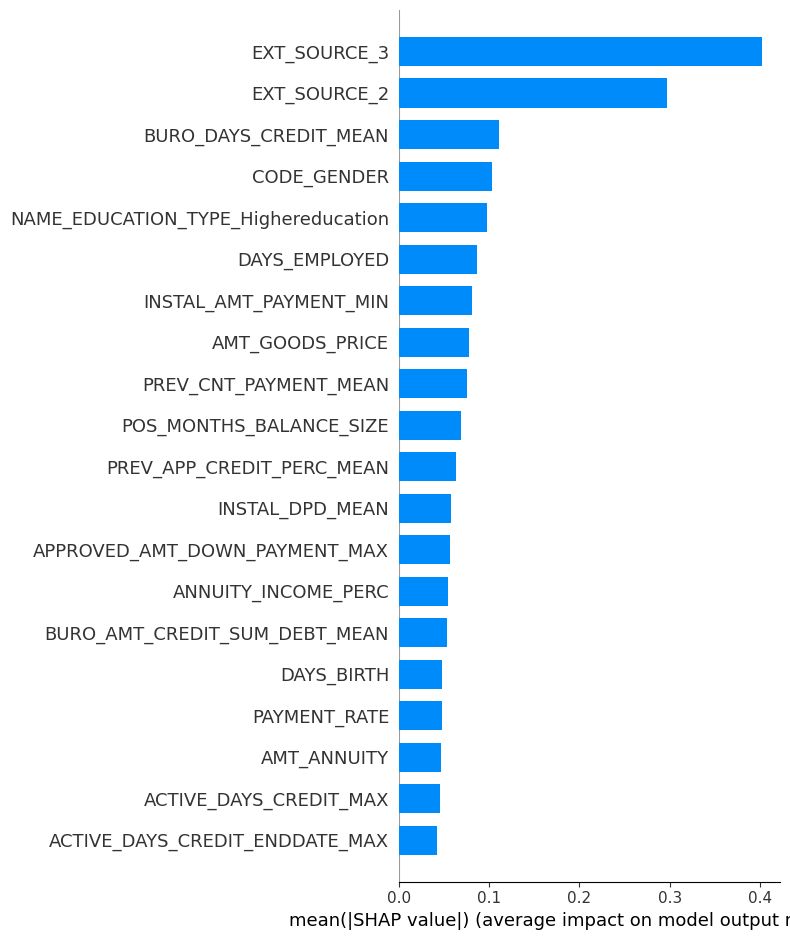

In [47]:
# Calculer les valeurs SHAP
model2_explainer = shap.TreeExplainer(LGBM_model)
model2_shap_values = model2_explainer.shap_values(X_test)

# Visualiser les valeurs SHAP
shap.summary_plot(model2_shap_values, X_test, plot_type='bar')

## Random Forest

### Model

In [48]:
# Initialiser le modèle Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Entraîner le modèle
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [49]:
# Prédire les probabilités pour la classe positive
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculer le score ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC Score: {roc_auc}")

ROC-AUC Score: 0.7294617954685125


### Feature Importance (most important features)

In [50]:
# Obtenir l'importance des caractéristiques
feature_importances = model.feature_importances_

# Créer un DataFrame pour afficher les importances des caractéristiques
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Afficher l'importance des caractéristiques
print("Importance des caractéristiques :")
print(feature_importance_df)

Importance des caractéristiques :
                                Feature  Importance
1                          EXT_SOURCE_3    0.083444
0                          EXT_SOURCE_2    0.061082
18                BURO_DAYS_CREDIT_MEAN    0.039532
2                         DAYS_EMPLOYED    0.035054
7                            DAYS_BIRTH    0.030369
6                    DAYS_EMPLOYED_PERC    0.029749
17               ACTIVE_DAYS_CREDIT_MAX    0.029372
27                       TOTALAREA_MODE    0.028714
19            PREV_APP_CREDIT_PERC_MEAN    0.028326
31               INSTAL_AMT_PAYMENT_MIN    0.028195
25       ACTIVE_DAYS_CREDIT_ENDDATE_MAX    0.027928
26                 BURO_DAYS_CREDIT_MAX    0.027702
11                  ANNUITY_INCOME_PERC    0.027355
5                          PAYMENT_RATE    0.027120
14        BURO_AMT_CREDIT_SUM_DEBT_MEAN    0.026801
33                    DAYS_REGISTRATION    0.026773
10                          AMT_ANNUITY    0.026626
29       INSTAL_DAYS_ENTRY_PAY

In [51]:
feature_importance_df.shape

(37, 2)

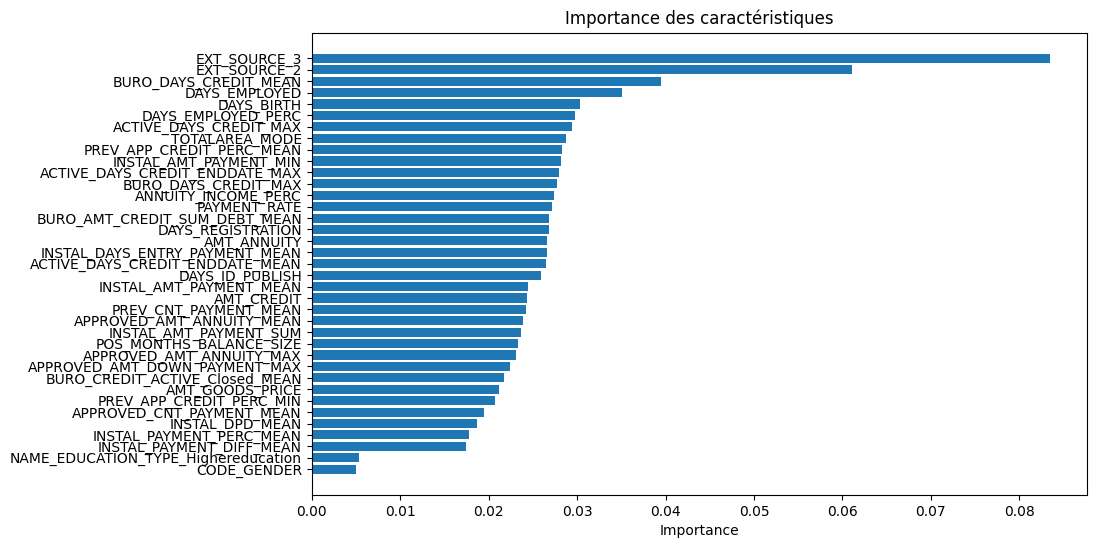

In [52]:
# Visualiser l'importance des caractéristiques
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Importance des caractéristiques')
plt.gca().invert_yaxis()  # Inverser l'axe y pour afficher la caractéristique la plus importante en haut
plt.show()

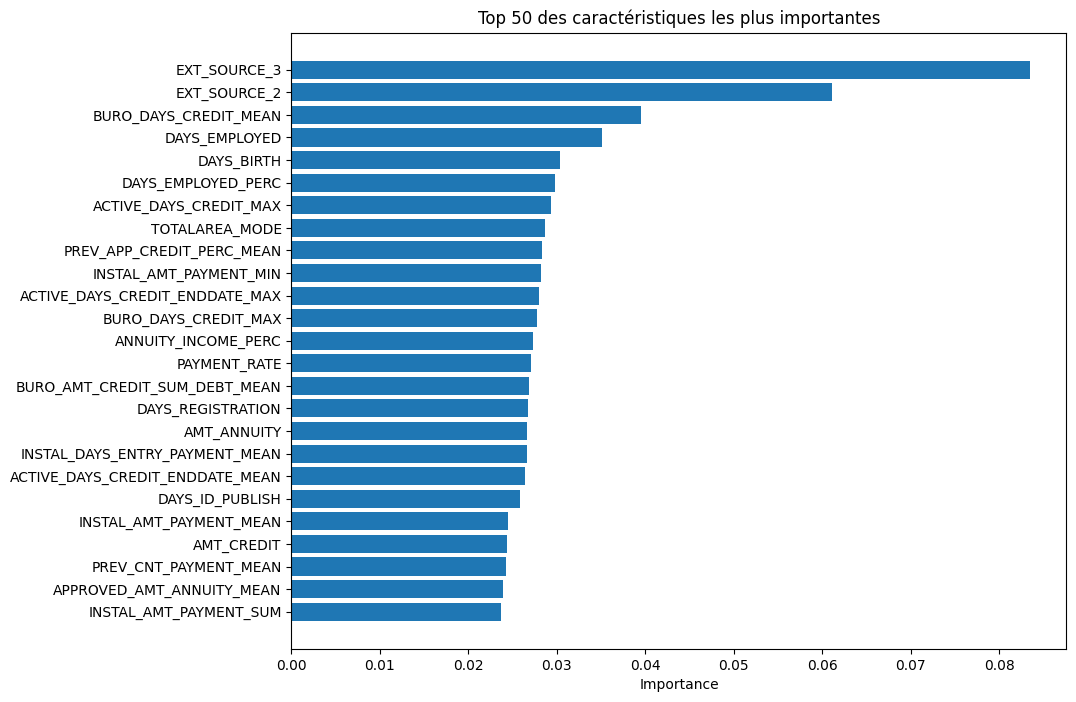

In [53]:
# Sélectionner le top des caractéristiques les plus importantes
top_features = feature_importance_df.head(25)

# Visualiser l'importance des caractéristiques
plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.title('Top 50 des caractéristiques les plus importantes')
plt.gca().invert_yaxis()  # Inverser l'axe y pour afficher la caractéristique la plus importante en haut
plt.show()

## Consolidation / Sélection Features

In [54]:
# Calculer l'importance moyenne absolue des valeurs SHAP pour chaque modèle
shap_importance_model1 = np.mean(np.abs(model1_shap_values), axis=0)
shap_importance_model2 = np.mean(np.abs(model2_shap_values), axis=0)

# Créer des DataFrames pour les importances SHAP
shap_importance_df_model1 = pd.DataFrame({
    'Feature': [f'Feature_{i}' for i in range(model1_shap_values.shape[1])],
    'Importance': shap_importance_model1
})

shap_importance_df_model2 = pd.DataFrame({
    'Feature': [f'Feature_{i}' for i in range(model2_shap_values.shape[1])],
    'Importance': shap_importance_model2
})

# Normaliser les importances pour chaque modèle
def normalize_importance(df):
    df['Importance'] = (df['Importance'] - df['Importance'].min()) / (df['Importance'].max() - df['Importance'].min())
    return df

shap_importance_df_model1 = normalize_importance(shap_importance_df_model1)
shap_importance_df_model2 = normalize_importance(shap_importance_df_model2)
feature_importance_df = normalize_importance(feature_importance_df)

# Combiner les importances normalisées
combined_importance = pd.DataFrame({
    'Feature': feature_importance_df['Feature'],
    'Combined_Importance': (shap_importance_df_model1['Importance'] +
                             shap_importance_df_model2['Importance'] +
                             feature_importance_df['Importance']) / 3,
    'XGBoost_Importance': shap_importance_df_model1['Importance'],
    'Light_GBM_Importance': shap_importance_df_model2['Importance'],
    'RandomForest_Importance': feature_importance_df['Importance']
})

# Trier les caractéristiques par leur importance combinée
combined_importance = combined_importance.sort_values(by='Combined_Importance', ascending=False)

# Sélectionner les 40 caractéristiques les plus importantes
top_40_features = combined_importance.head(40)

# Afficher les 40 caractéristiques les plus importantes
print("Top 40 des caractéristiques les plus importantes :")
print(top_40_features)

Top 40 des caractéristiques les plus importantes :
                                Feature  Combined_Importance  \
1                          EXT_SOURCE_3             1.000000   
0                          EXT_SOURCE_2             0.733223   
18                BURO_DAYS_CREDIT_MEAN             0.325860   
2                         DAYS_EMPLOYED             0.277510   
31               INSTAL_AMT_PAYMENT_MIN             0.222854   
8                 PREV_CNT_PAYMENT_MEAN             0.209289   
9                       AMT_GOODS_PRICE             0.199253   
21              POS_MONTHS_BALANCE_SIZE             0.195464   
19            PREV_APP_CREDIT_PERC_MEAN             0.193449   
7                            DAYS_BIRTH             0.183966   
11                  ANNUITY_INCOME_PERC             0.180201   
14        BURO_AMT_CREDIT_SUM_DEBT_MEAN             0.177360   
17               ACTIVE_DAYS_CREDIT_MAX             0.172002   
4                           CODE_GENDER             0

## Réduction DF

In [55]:
top_40_features_target = top_40_features.copy()
top_40_features_target.loc[-1] = 'TARGET'

In [56]:
# Réduire dataframe
df_reduced = df[top_40_features_target['Feature']]
df_reduced.shape

(74878, 38)

In [57]:
# Calculer le nombre total de valeurs manquantes
total_missing = df_reduced.isna().sum().sum()

# Calculer le pourcentage de valeurs manquantes
total_cells = df_reduced.size
percentage_missing = (total_missing / total_cells) * 100

# Afficher le total et le pourcentage de valeurs manquantes
print(f"Total de cellules dans df_reduced: {total_cells}")
print(f"Total de valeurs manquantes dans df_reduced: {total_missing}")
print(f"Pourcentage de valeurs manquantes dans df_reduced: {percentage_missing:.2f}%")

Total de cellules dans df_reduced: 2845364
Total de valeurs manquantes dans df_reduced: 0
Pourcentage de valeurs manquantes dans df_reduced: 0.00%


In [58]:
missing_values_count(df_reduced)

Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :
         Number of Variables  Percentage of Total
0%                        38                100.0
0-20%                      0                  0.0
20-40%                     0                  0.0
40-60%                     0                  0.0
60-100%                    0                  0.0


In [59]:
missing_values = df_reduced.isna().sum()
missing_percentage = (missing_values / len(df_reduced)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage (%)': missing_percentage
})

# Afficher les valeurs manquantes et les pourcentages
print("Valeurs manquantes et pourcentages dans df_reduced :")
print(missing_info)

Valeurs manquantes et pourcentages dans df_reduced :
                                     Missing Values  Missing Percentage (%)
EXT_SOURCE_3                                      0                     0.0
EXT_SOURCE_2                                      0                     0.0
BURO_DAYS_CREDIT_MEAN                             0                     0.0
DAYS_EMPLOYED                                     0                     0.0
INSTAL_AMT_PAYMENT_MIN                            0                     0.0
PREV_CNT_PAYMENT_MEAN                             0                     0.0
AMT_GOODS_PRICE                                   0                     0.0
POS_MONTHS_BALANCE_SIZE                           0                     0.0
PREV_APP_CREDIT_PERC_MEAN                         0                     0.0
DAYS_BIRTH                                        0                     0.0
ANNUITY_INCOME_PERC                               0                     0.0
BURO_AMT_CREDIT_SUM_DEBT_MEAN      

Text(0.5, 1.0, "Heatmap des corrélations - 'application_train'")

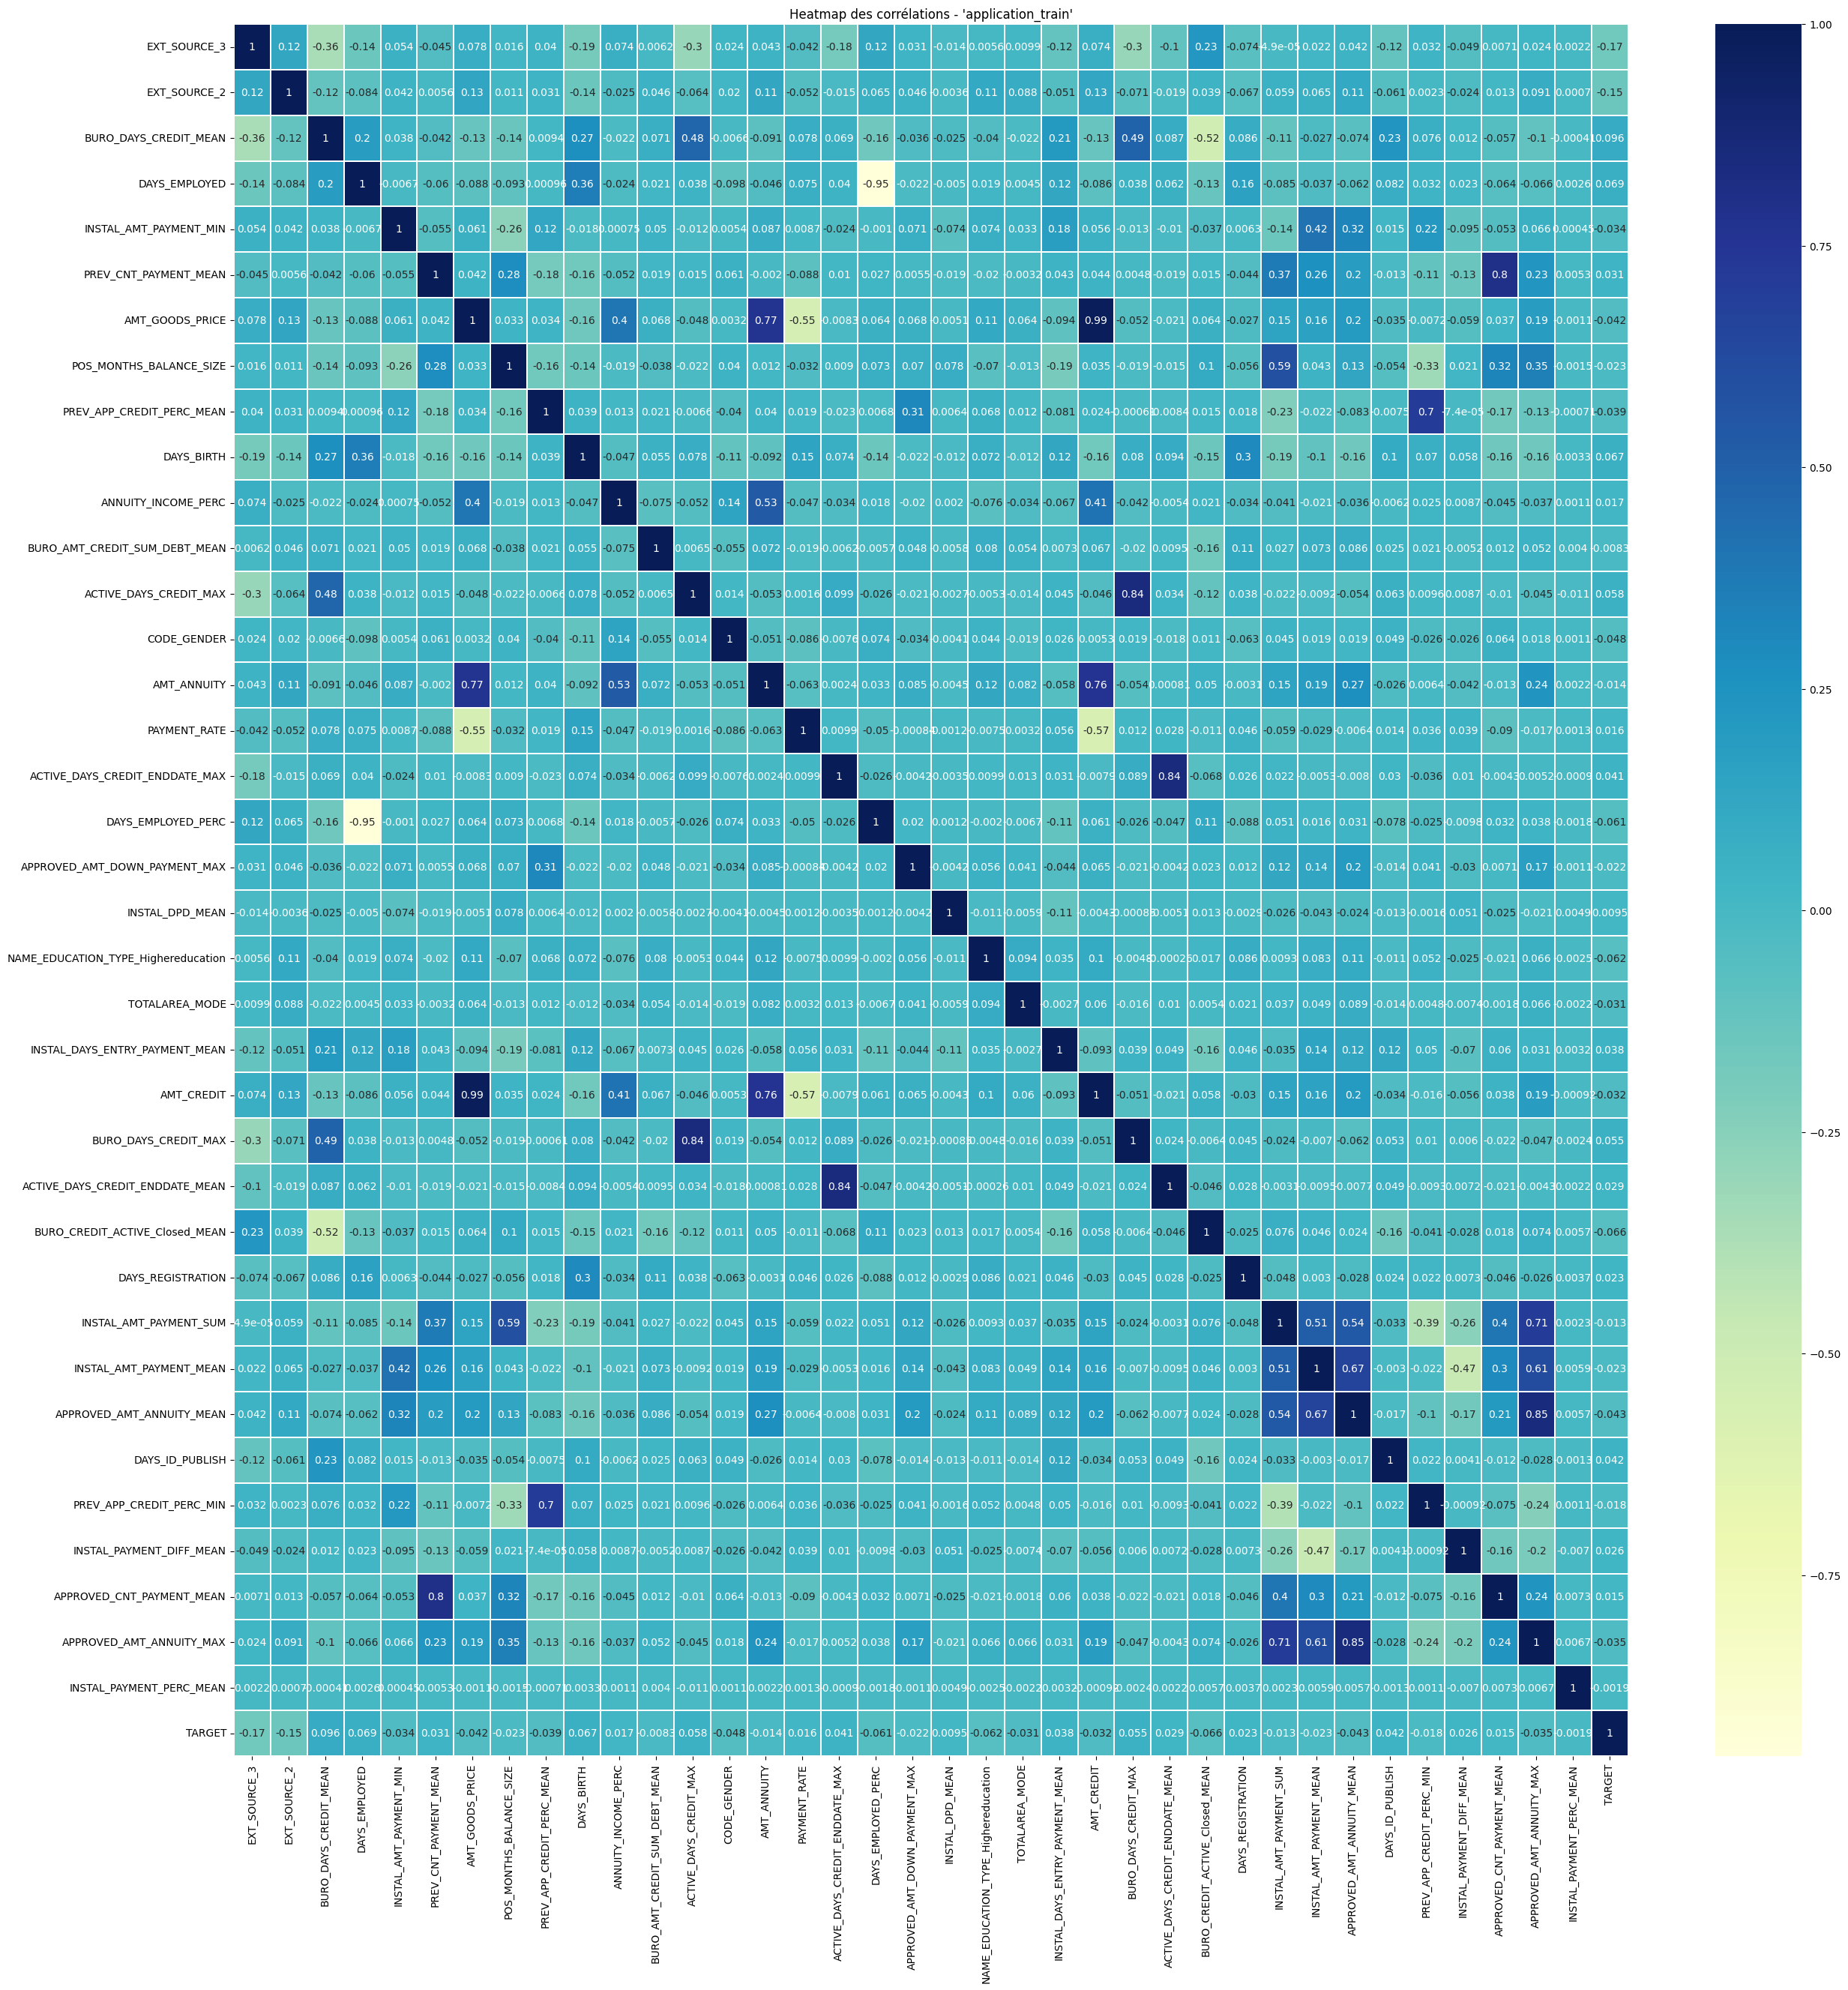

In [60]:
# Affichage de la heatmap des corrélations
plt.figure(figsize=(30,30))
sns.heatmap(df_reduced.corr() , annot=True, linewidths=.2, cmap="YlGnBu")
plt.title("Heatmap des corrélations - 'application_train'")

In [61]:
df_reduced.head()

,EXT_SOURCE_3,EXT_SOURCE_2,BURO_DAYS_CREDIT_MEAN,DAYS_EMPLOYED,INSTAL_AMT_PAYMENT_MIN,PREV_CNT_PAYMENT_MEAN,AMT_GOODS_PRICE,POS_MONTHS_BALANCE_SIZE,PREV_APP_CREDIT_PERC_MEAN,DAYS_BIRTH,...,INSTAL_AMT_PAYMENT_SUM,INSTAL_AMT_PAYMENT_MEAN,APPROVED_AMT_ANNUITY_MEAN,DAYS_ID_PUBLISH,PREV_APP_CREDIT_PERC_MIN,INSTAL_PAYMENT_DIFF_MEAN,APPROVED_CNT_PAYMENT_MEAN,APPROVED_AMT_ANNUITY_MAX,INSTAL_PAYMENT_PERC_MEAN,TARGET
0,0.139376,0.262949,-874.000000,-637.0,9251.775391,24.000,351000.0,19.0,1.000000,-9461,...,219625.687500,11559.247070,9251.775391,-2120,1.000000,0.000000,24.0,9251.775391,1.000000,1.0
1,0.176653,0.715042,-618.428589,-2717.0,3.960000,17.000,67500.0,67.0,1.067748,-13439,...,620981.812500,8391.646484,8593.155273,-3227,0.909881,2348.182617,17.0,14480.459961,0.837838,0.0
2,0.556727,0.706428,-337.000000,-7804.0,6765.975098,18.000,157500.0,7.0,0.863260,-17718,...,47361.824219,6765.975098,6765.975098,-1259,0.863260,0.000000,18.0,6765.975098,1.000000,0.0
3,0.358951,0.457143,-679.000000,-4306.0,23531.175781,21.000,450000.0,11.0,0.953326,-11146,...,954356.750000,119294.593750,33193.664062,-2518,0.906651,0.000000,21.0,42778.843750,1.000000,0.0
4,0.461482,0.651406,-930.833313,-3494.0,9035.684570,8.625,225000.0,14.0,1.040316,-19334,...,70923.867188,11820.644531,6704.370117,-2893,0.949873,0.000000,5.0,9035.684570,1.000000,0.0
